In [ ]:
import requests
from bs4 import BeautifulSoup
import json
import hashlib
import os
import time
import pandas as pd
from google.colab import files  # To download files later

# 2. Create directories for data
# We need a folder for images and one for the text file
os.makedirs('dataset/images', exist_ok=True)
print("Setup Complete. Folder 'dataset/images' created.")

Setup Complete. Folder 'dataset/images' created.


In [ ]:
!pip install beautifulsoup4 requests pandas

In [ ]:
def get_md5(url):
    """Generates a unique ID for each article based on its URL."""
    return hashlib.md5(url.encode()).hexdigest()

def scrape_factcheck_org(pages_to_scrape=2):
    """
    Scrapes the latest articles from FactCheck.org.
    pages_to_scrape: How many pages of results to fetch (default 2).
    """
    base_url = "https://www.factcheck.org/page/{}/"
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
    }

    scraped_data = []

    print(f"--- Starting Scraper for {pages_to_scrape} pages ---")

    for page_num in range(1, pages_to_scrape + 1):
        url = base_url.format(page_num)
        print(f"Scanning Page {page_num}...")

        try:
            response = requests.get(url, headers=headers)
            if response.status_code != 200:
                print(f"Failed to load page {page_num}")
                continue

            soup = BeautifulSoup(response.content, 'html.parser')

            # Find all article headers on the main page
            articles = soup.find_all('article')

            for art in articles:
                # 1. Get Link & Title
                title_tag = art.find('h3', class_='entry-title')
                if not title_tag: continue

                link = title_tag.find('a')['href']
                title = title_tag.get_text(strip=True)
                post_id = get_md5(link)

                # 2. Visit the Article Page (Deep Dive)
                print(f"  -> Fetching: {title[:30]}...")
                art_resp = requests.get(link, headers=headers)
                art_soup = BeautifulSoup(art_resp.content, 'html.parser')

                # 3. Extract Details
                # DATE
                date_tag = art_soup.find('time', class_='entry-date')
                date = date_tag.get_text() if date_tag else "Unknown"

                # IMAGE (Find the main image)
                img_tag = art_soup.find('div', class_='entry-content').find('img')
                img_url = img_tag['src'] if img_tag else None

                # TEXT (Get all paragraph text)
                content_div = art_soup.find('div', class_='entry-content')
                text_paragraphs = [p.get_text() for p in content_div.find_all('p')]
                full_text = " ".join(text_paragraphs)

                # VERDICT / CLAIM (FactCheck.org doesn't always have a strict label in HTML,
                # so we often use the title or first bolded text as the 'claim' proxy)
                # For this tailored scraper, we will infer it.

                entry = {
                    "post_id": post_id,
                    "site": "factcheck.org",  # Domain Label for your GRL
                    "title": title,
                    "date": date,
                    "text": full_text,
                    "image_url": img_url,
                    "url": link
                }

                # 4. Download Image (Critical for your Multimodal Model)
                if img_url:
                    try:
                        img_data = requests.get(img_url, headers=headers).content
                        # Save as: dataset/images/postID.jpg
                        ext = img_url.split('.')[-1].split('?')[0] # get .jpg or .png
                        if len(ext) > 4: ext = "jpg"

                        img_filename = f"dataset/images/{post_id}.{ext}"
                        with open(img_filename, 'wb') as handler:
                            handler.write(img_data)

                        entry['local_image_path'] = img_filename
                    except:
                        entry['local_image_path'] = None
                else:
                    entry['local_image_path'] = None

                scraped_data.append(entry)

                # Be polite to the server
                time.sleep(1)

        except Exception as e:
            print(f"Error on page {page_num}: {e}")

    return scraped_data

In [ ]:
# 1. Run the scraper (Try 2 pages first to be quick)
data = scrape_factcheck_org(pages_to_scrape=2)

print(f"\nScraping Finished! Collected {len(data)} articles.")

# 2. Save to JSONL (JSON Lines) - Best format for large text datasets
output_file = 'dataset/output.jsonl'
with open(output_file, 'w') as f:
    for entry in data:
        json.dump(entry, f)
        f.write('\n')

print(f"Data saved to {output_file}")

# 3. Quick Peek at the Data
df = pd.DataFrame(data)
print("\n--- Data Preview ---")
print(df[['site', 'title', 'local_image_path']].head())

# 4. OPTIONAL: Download the file to your computer
# files.download(output_file)

--- Starting Scraper for 2 pages ---
Scanning Page 1...
  -> Fetching: WHO Didn’t Recommend Lockdowns...
  -> Fetching: Manufacturing Construction Spe...
  -> Fetching: Trump’s Immediate Speculation ...
  -> Fetching: Americans Don’t Need ‘Dramatic...
  -> Fetching: Trump’s Selective Comparison O...
  -> Fetching: Trump’s Aspirin Use and Doctor...
  -> Fetching: As ICE Arrests Increased, a Hi...
  -> Fetching: Patel’s Remarks Conflict With ...
  -> Fetching: Video Analyses at Odds with DH...
  -> Fetching: Trump’s Claims About Greenland...
Scanning Page 2...
  -> Fetching: Trump’s Tariffs Don’t Come Clo...
  -> Fetching: Trump’s Numbers, Second Term...
  -> Fetching: The Threat of the Insurrection...
  -> Fetching: The Facts on the Vaccines the ...
  -> Fetching: Explaining Trump’s Claim That ...
  -> Fetching: Politicians Reach Different Co...
  -> Fetching: Trump Waters Down Colorado’s P...
  -> Fetching: Exploring the Legality Questio...
  -> Fetching: Makary, RFK Jr. Exaggerate Chr

**The PolitiFact Scraper**

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import os
import time
import hashlib

# 1. Setup
os.makedirs('dataset/political_images', exist_ok=True)

def get_politifact_data(pages=5):
    """
    Scrapes PolitiFact.com for political fake news.
    Args:
        pages: Number of pages to scrape (1 page ≈ 30 articles)
    """
    base_url = "https://www.politifact.com/factchecks/list/?page={}"
    headers = {'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7)'}

    data = []
    print(f"--- Scraping {pages} pages from PolitiFact ---")

    for p in range(1, pages + 1):
        print(f"Processing Page {p}...")
        try:
            response = requests.get(base_url.format(p), headers=headers)
            soup = BeautifulSoup(response.content, 'html.parser')

            # Find all fact-check items
            items = soup.find_all('li', class_='o-listicle__item')

            for item in items:
                # A. Extract Text (The Claim)
                quote_div = item.find('div', class_='m-statement__quote')
                if not quote_div: continue

                text = quote_div.get_text(strip=True)
                link = "https://www.politifact.com" + quote_div.find('a')['href']

                # B. Extract Verdict (The Label)
                # PolitiFact stores rating in the alt tag of the meter image
                meter_div = item.find('div', class_='m-statement__meter')
                if meter_div and meter_div.find('img'):
                    verdict = meter_div.find('img')['alt'] # e.g., "true", "false", "pants-fire"
                else:
                    verdict = "unknown"

                # C. Extract Image (The Person/Context)
                # This is the image of the politician or subject
                img_div = item.find('div', class_='m-statement__image')
                img_url = None
                if img_div and img_div.find('img'):
                    img_url = img_div.find('img')['src']

                # Generate ID
                post_id = hashlib.md5(text.encode()).hexdigest()

                entry = {
                    "id": post_id,
                    "text": text,
                    "verdict": verdict,
                    "img_url": img_url,
                    "source_url": link,
                    "domain": "politics" # Useful for your Domain Adversarial layer later
                }

                # D. Download Image
                if img_url:
                    try:
                        img_data = requests.get(img_url, headers=headers).content
                        ext = "jpg"
                        filename = f"dataset/political_images/{post_id}.{ext}"
                        with open(filename, 'wb') as f:
                            f.write(img_data)
                        entry['local_img_path'] = filename
                    except:
                        entry['local_img_path'] = None

                data.append(entry)

            # Be polite to the server
            time.sleep(1)

        except Exception as e:
            print(f"Error on page {p}: {e}")

    return data

# --- EXECUTION ---
# Scrape 5 pages (approx 150 articles) to start
political_data = get_politifact_data(pages=5)

# Save
df = pd.DataFrame(political_data)
df.to_json('dataset/political_data.jsonl', orient='records', lines=True)

print(f"\nSUCCESS: Collected {len(df)} political fact-checks.")
print(df[['verdict', 'text']].head())

--- Scraping 5 pages from PolitiFact ---
Processing Page 1...
Processing Page 2...
Processing Page 3...
Processing Page 4...
Processing Page 5...

SUCCESS: Collected 150 political fact-checks.
      verdict                                               text
0       false  “Durante su presentación en el Super Bowl, Bad...
1  pants-fire  An image shows Bad Bunny wearing a dress and b...
2   half-true  “We right now have more factories and plants b...
3       false  During the Super Bowl halftime show, “Bad Bunn...
4  pants-fire  An image shows Jeffrey Epstein “still alive an...


**Phase 2: The Data Loader (Feeding PyTorch)**

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from transformers import BertTokenizer
from PIL import Image
import pandas as pd
import os

class PoliticalDataset(Dataset):
    def __init__(self, json_file, max_len=128):
        # 1. Load Data
        self.data = pd.read_json(json_file, lines=True)

        # 2. Initialize BERT Tokenizer
        self.tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
        self.max_len = max_len

        # 3. Image Transforms (Standard for ResNet)
        self.img_transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])

        # 4. Map Verdicts to Binary Labels (Fake=1, Real=0)
        self.label_map = {
            'pants-fire': 1, 'false': 1, 'mostly-false': 1, 'barely-true': 1, # FAKE
            'half-true': 0, 'mostly-true': 0, 'true': 0, # REAL
            'unknown': 1
        }

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]

        # --- A. PROCESS TEXT (THE FIX IS HERE) ---
        text = str(row['text'])

        # We call the tokenizer directly instead of .encode_plus
        inputs = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )

        # --- B. PROCESS IMAGE ---
        img_path = row['local_img_path']

        # If image exists and is valid
        if img_path and os.path.exists(img_path):
            try:
                image = Image.open(img_path).convert('RGB')
                image = self.img_transform(image)
            except:
                image = torch.zeros(3, 224, 224)
        else:
            image = torch.zeros(3, 224, 224)

        # --- C. PROCESS LABEL ---
        label_str = row['verdict']
        label = self.label_map.get(label_str, 1)

        return {
            'input_ids': inputs['input_ids'].flatten(),
            'attention_mask': inputs['attention_mask'].flatten(),
            'pixel_values': image,
            'label': torch.tensor(label, dtype=torch.float)
        }

# --- TEST IT AGAIN ---
dataset = PoliticalDataset('dataset/political_data.jsonl')
loader = DataLoader(dataset, batch_size=4, shuffle=True)

try:
    sample = next(iter(loader))
    print("--- Data Loader Check ---")
    print(f"Text Shape: {sample['input_ids'].shape} (Should be [4, 128])")
    print(f"Image Shape: {sample['pixel_values'].shape} (Should be [4, 3, 224, 224])")
    print("SUCCESS: Data Loader is working!")
except Exception as e:
    print(f"Still failing: {e}")

--- Data Loader Check ---
Text Shape: torch.Size([4, 128]) (Should be [4, 128])
Image Shape: torch.Size([4, 3, 224, 224]) (Should be [4, 3, 224, 224])
SUCCESS: Data Loader is working!


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import BertModel
from torchvision import models
from torch.autograd import Function

# ==========================================
# PART 1: The Gradient Reversal Layer (GRL)
# ==========================================
# This is the "Magic" switch.
# Forward pass: It does nothing (Identity).
# Backward pass: It reverses gradients to confuse the Domain Classifier.
class GradientReversalFn(Function):
    @staticmethod
    def forward(ctx, x, alpha):
        ctx.alpha = alpha
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return grad_output.neg() * ctx.alpha, None

# ==========================================
# PART 2: Cross-Modal Attention (CMA)
# ==========================================
# This finds the "Mismatch" between Text and Image
class CMA_Fusion(nn.Module):
    def __init__(self, text_dim=768, img_dim=2048, shared_dim=512):
        super(CMA_Fusion, self).__init__()

        # Project both to same size (512)
        self.text_proj = nn.Linear(text_dim, shared_dim)
        self.img_proj = nn.Linear(img_dim, shared_dim)

        # Attention Layers
        self.query = nn.Linear(shared_dim, shared_dim)
        self.key = nn.Linear(shared_dim, shared_dim)
        self.value = nn.Linear(shared_dim, shared_dim)

    def forward(self, text_feats, img_feats):
        # text_feats: [Batch, 128 (seq), 768] -> [Batch, 128, 512]
        # img_feats:  [Batch, 49 (regions), 2048] -> [Batch, 49, 512]

        T = F.relu(self.text_proj(text_feats))
        I = F.relu(self.img_proj(img_feats))

        # Calculate Attention (Text-Guided Image Attention)
        # "Which image regions match these words?"
        Q = self.query(T)
        K = self.key(I)

        # Attention Scores
        # [Batch, Seq_Len, Num_Regions]
        scores = torch.bmm(Q, K.transpose(1, 2)) / (512**0.5)
        attn_weights = F.softmax(scores, dim=-1) # SAVE THIS FOR HEATMAPS LATER

        # Apply Attention to Image
        V = self.value(I)
        fused_context = torch.bmm(attn_weights, V) # [Batch, Seq_Len, 512]

        # Fuse: Combine original Text + Attended Image
        combined = torch.cat([T, fused_context], dim=-1) # [Batch, Seq_Len, 1024]

        # Pooling: Average over all words to get 1 vector per article
        final_vector = torch.mean(combined, dim=1) # [Batch, 1024]

        return final_vector, attn_weights

# ==========================================
# PART 3: The Main DAM-CMA Model
# ==========================================
class DAM_CMA_Model(nn.Module):
    def __init__(self):
        super(DAM_CMA_Model, self).__init__()

        # A. Encoders (Frozen to save time)
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        self.resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        # Remove ResNet classification head (we want the 7x7 grid features)
        self.resnet_modules = list(self.resnet.children())[:-2]
        self.resnet_backbone = nn.Sequential(*self.resnet_modules)

        # Freeze params
        for param in self.bert.parameters(): param.requires_grad = False
        for param in self.resnet_backbone.parameters(): param.requires_grad = False

        # B. Fusion Layer
        self.cma = CMA_Fusion()

        # C. Task Classifier (Fake vs Real)
        # Input is 1024 (from CMA)
        self.label_classifier = nn.Sequential(
            nn.Linear(1024, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1) # Binary Output
        )

        # D. Domain Classifier (Adversarial)
        # Tries to guess: "Is this Politics or Sports?"
        self.domain_classifier = nn.Sequential(
            nn.Linear(1024, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1) # Simple Binary Domain (Politics vs Other)
        )

    def forward(self, input_ids, attention_mask, pixel_values, alpha=1.0):
        # 1. Extract Features
        text_out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        text_feats = text_out.last_hidden_state # [Batch, 128, 768]

        img_out = self.resnet_backbone(pixel_values) # [Batch, 2048, 7, 7]
        img_feats = img_out.view(img_out.size(0), 2048, -1).permute(0, 2, 1) # [Batch, 49, 2048]

        # 2. Fuse (CMA)
        fused_vec, attn_weights = self.cma(text_feats, img_feats)

        # 3. Head A: Fake News Detection
        label_pred = self.label_classifier(fused_vec)

        # 4. Head B: Domain Adversarial Training
        # Reverse the gradient!
        reverse_vec = GradientReversalFn.apply(fused_vec, alpha)
        domain_pred = self.domain_classifier(reverse_vec)

        return label_pred, domain_pred, attn_weights

# ==========================================
# PART 4: Verification (Run this immediately)
# ==========================================
# Initialize model
model = DAM_CMA_Model()

# Move batch to same device as model (CPU for now is fine for test)
sample_text = sample['input_ids']
sample_mask = sample['attention_mask']
sample_img = sample['pixel_values']

print("\n--- Model Architecture Check ---")
# Run Forward Pass
fake_score, domain_score, attns = model(sample_text, sample_mask, sample_img)

print(f"Fake/Real Score Shape: {fake_score.shape} (Should be [4, 1])")
print(f"Domain Score Shape:    {domain_score.shape} (Should be [4, 1])")
print(f"Attention Map Shape:   {attns.shape} (Should be [4, 128, 49])")
print("SUCCESS: DAM-CMA Model is built and runnable!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 163MB/s]


NameError: name 'sample' is not defined

**Phase 4: The Adversarial Training Loop**



**Balancing two opposing goals:**





*   Label Predictor (LP): Must get better (Minimize Error).
*   Domain Classifier (DC): Must get worse (Maximize Error / Confusion).


We achieve this using the alpha parameter in the GRL layer.



*   Start of Training (alpha=0): The model focuses only on learning to detect Fake News. The Adversarial part is turned off.
*   End of Training (alpha=1): The Adversarial part is fully active, forcing the model to unlearn any "political" or "sports" specific bias.





In [ ]:
import torch.optim as optim
import numpy as np

# ==========================================
# CONFIGURATION
# ==========================================
EPOCHS = 5           # Small number for testing
LR = 2e-5            # Learning Rate (Standard for BERT)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# ==========================================
# THE TRAINING LOOP
# ==========================================
def train_dam_cma(model, loader, epochs=3):
    print(f"Starting Training on {DEVICE}...")
    model.to(DEVICE)

    # Optimizer
    optimizer = optim.AdamW(model.parameters(), lr=LR)

    # Loss Function (Binary Cross Entropy)
    criterion = nn.BCEWithLogitsLoss()

    for epoch in range(epochs):
        model.train()
        total_label_loss = 0
        total_domain_loss = 0
        correct_labels = 0
        total_samples = 0

        # Calculate Alpha for GRL (scales from 0.0 to 1.0 over epochs)
        # This helps training stability
        p = float(epoch) / epochs
        alpha = 2. / (1. + np.exp(-10 * p)) - 1

        print(f"\n--- Epoch {epoch+1}/{epochs} (Alpha: {alpha:.2f}) ---")

        for batch_idx, batch in enumerate(loader):
            # 1. Move data to GPU/CPU
            input_ids = batch['input_ids'].to(DEVICE)
            mask = batch['attention_mask'].to(DEVICE)
            pixel_values = batch['pixel_values'].to(DEVICE)

            # Label (Fake vs Real)
            labels = batch['label'].to(DEVICE).unsqueeze(1)

            # Domain Label (Politics vs Other)
            # Since we scraped only Politics for now, let's create a dummy domain
            # (0 = Politics). In full version, this comes from the dataset.
            domain_labels = torch.zeros_like(labels).to(DEVICE)

            # 2. Zero Gradients
            optimizer.zero_grad()

            # 3. Forward Pass
            # Pass alpha to control the Adversarial strength
            label_pred, domain_pred, _ = model(input_ids, mask, pixel_values, alpha=alpha)

            # 4. Calculate Losses
            # Task A: Main Misinformation Detection
            loss_label = criterion(label_pred, labels)

            # Task B: Domain Classification
            loss_domain = criterion(domain_pred, domain_labels)

            # Total Loss = Label Loss + Domain Loss
            # Note: GRL inside the model handles the "negative" gradient for domain automatically
            total_loss = loss_label + loss_domain

            # 5. Backward Pass
            total_loss.backward()
            optimizer.step()

            # 6. Metrics
            total_label_loss += loss_label.item()
            total_domain_loss += loss_domain.item()

            # Calculate Accuracy
            preds = torch.sigmoid(label_pred) > 0.5
            correct_labels += (preds == labels).sum().item()
            total_samples += labels.size(0)

            if batch_idx % 10 == 0:
                print(f"  Batch {batch_idx}: L_Label={loss_label.item():.4f} | L_Domain={loss_domain.item():.4f}")

        # Epoch Summary
        avg_acc = (correct_labels / total_samples) * 100
        print(f"EPOCH {epoch+1} DONE: Label Loss={total_label_loss/len(loader):.4f} | Accuracy={avg_acc:.2f}%")

# ==========================================
# EXECUTE
# ==========================================
# 1. Re-initialize model to start fresh
model = DAM_CMA_Model()

# 2. Run Training
train_dam_cma(model, loader, epochs=EPOCHS)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Starting Training on cpu...

--- Epoch 1/5 (Alpha: 0.00) ---
  Batch 0: L_Label=0.6695 | L_Domain=0.6806
  Batch 10: L_Label=0.6067 | L_Domain=0.6510
  Batch 20: L_Label=0.6212 | L_Domain=0.6078
  Batch 30: L_Label=0.6184 | L_Domain=0.5875
EPOCH 1 DONE: Label Loss=0.6304 | Accuracy=81.33%

--- Epoch 2/5 (Alpha: 0.76) ---
  Batch 0: L_Label=0.5204 | L_Domain=0.5617
  Batch 10: L_Label=0.5080 | L_Domain=0.5559
  Batch 20: L_Label=0.4775 | L_Domain=0.5506
  Batch 30: L_Label=0.5781 | L_Domain=0.5549
EPOCH 2 DONE: Label Loss=0.5769 | Accuracy=81.33%

--- Epoch 3/5 (Alpha: 0.96) ---
  Batch 0: L_Label=0.4297 | L_Domain=0.5334
  Batch 10: L_Label=0.4475 | L_Domain=0.5402
  Batch 20: L_Label=0.4180 | L_Domain=0.5378
  Batch 30: L_Label=0.7672 | L_Domain=0.5393
EPOCH 3 DONE: Label Loss=0.5446 | Accuracy=81.33%

--- Epoch 4/5 (Alpha: 1.00) ---
  Batch 0: L_Label=0.4303 | L_Domain=0.5322
  Batch 10: L_Label=0.5742 | L_Domain=0.5378
  Batch 20: L_Label=0.5727 | L_Domain=0.5384
  Batch 30: L_Label

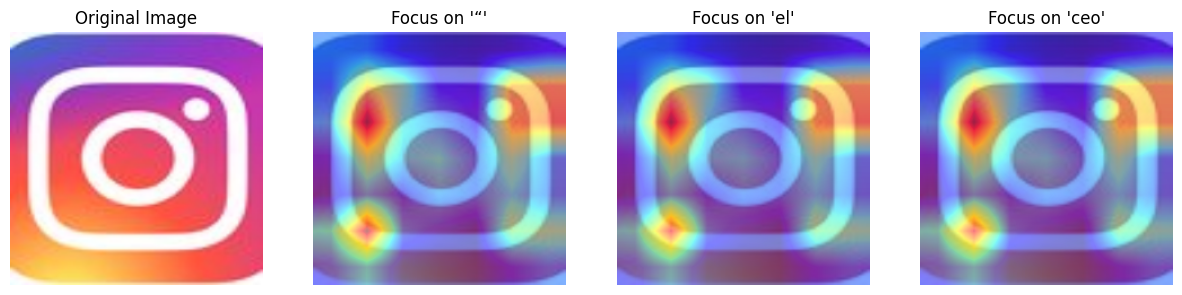

Full Sentence: [CLS] “ el ceo de coca - cola , james qui ##nce ##y , lan ##zo un ultimatum con ##tu ##nden ##te : cancel ##en la act ##ua ##cion de bad bunny en el super bowl o la marc ##a term ##ina ##ra su pat ##ro ##cini ##o del event ##o . ” [SEP]


In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

def visualize_attention(model, loader, tokenizer, sample_index=0):
    model.eval()

    # 1. Get a single batch
    batch = next(iter(loader))

    # Move to device
    input_ids = batch['input_ids'].to(DEVICE)
    mask = batch['attention_mask'].to(DEVICE)
    pixel_values = batch['pixel_values'].to(DEVICE)

    # 2. Run Model to get Attention Weights
    # We don't care about predictions here, just the 'attns' output
    with torch.no_grad():
        _, _, attns = model(input_ids, mask, pixel_values, alpha=0)

    # Shape of attns: [Batch, Seq_Len, 49]
    # (49 comes from 7x7 grid of ResNet)

    # 3. Select the Data Sample
    # Let's look at the first item in the batch
    attn_map = attns[sample_index] # Shape: [128, 49]
    token_ids = input_ids[sample_index]

    # Decode text back to words so we can read them
    tokens = tokenizer.convert_ids_to_tokens(token_ids)

    # 4. Find Interesting Words to Visualize
    # We skip [CLS], [SEP], and [PAD] to find real words
    valid_indices = [i for i, t in enumerate(tokens) if t not in ['[CLS]', '[SEP]', '[PAD]']]

    # Let's pick the first 3 meaningful words to visualize
    target_word_indices = valid_indices[:3]

    # 5. Plotting
    # Get original image (Un-normalize it for display)
    img_tensor = pixel_values[sample_index].cpu()
    # Undo the standard ImageNet normalization
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img_display = (img_tensor * std + mean).permute(1, 2, 0).numpy()
    img_display = np.clip(img_display, 0, 1)

    plt.figure(figsize=(15, 5))

    # Subplot 1: Original Image
    plt.subplot(1, 4, 1)
    plt.imshow(img_display)
    plt.title("Original Image")
    plt.axis('off')

    # Subplot 2, 3, 4: Heatmaps for specific words
    for i, word_idx in enumerate(target_word_indices):
        word = tokens[word_idx]

        # Get attention score for this word across all 49 regions
        # Shape: [49]
        word_attn = attn_map[word_idx].cpu().numpy()

        # Reshape to 7x7 (ResNet Grid)
        heatmap = word_attn.reshape(7, 7)

        # Upscale 7x7 -> 224x224 (Image Size)
        heatmap = cv2.resize(heatmap, (224, 224))

        # Normalize heatmap to 0-1 for brightness
        heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)

        plt.subplot(1, 4, i+2)
        plt.imshow(img_display)
        plt.imshow(heatmap, cmap='jet', alpha=0.5) # Alpha blends heatmap over image
        plt.title(f"Focus on '{word}'")
        plt.axis('off')

    plt.show()
    print(f"Full Sentence: {' '.join([t for t in tokens if t != '[PAD]'])}")

# --- RUN IT ---
# Passing the 'dataset.tokenizer' we created in Phase 2
visualize_attention(model, loader, dataset.tokenizer)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Create a permanent folder for your dataset
import os
base_path = '/content/drive/My Drive/DAM-CMA-Dataset'
os.makedirs(f'{base_path}/images', exist_ok=True)
print(f"Saving data to: {base_path}")

Mounted at /content/drive
Saving data to: /content/drive/My Drive/DAM-CMA-Dataset


In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import os
import time
import hashlib
import json

# --- CONFIGURATION ---
START_PAGE = 1
END_PAGE = 100       # Change to 500 or 1000 for massive data!
SAVE_INTERVAL = 10   # Save to Drive every 10 pages

# File paths in Google Drive
data_file = f'{base_path}/politifact_bulk.jsonl'
image_dir = f'{base_path}/images'

def save_batch(data_buffer):
    """Appends a list of dictionaries to the JSONL file in Drive."""
    with open(data_file, 'a') as f:
        for entry in data_buffer:
            json.dump(entry, f)
            f.write('\n')
    print(f"  -> Saved {len(data_buffer)} articles to Drive.")

def get_politifact_bulk():
    headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)'}
    data_buffer = []
    total_collected = 0

    print(f"--- STARTING BULK SCRAPE (Pages {START_PAGE} to {END_PAGE}) ---")

    for p in range(START_PAGE, END_PAGE + 1):
        print(f"Scanning Page {p}...", end=" ")
        try:
            url = f"https://www.politifact.com/factchecks/list/?page={p}"
            response = requests.get(url, headers=headers, timeout=10)
            soup = BeautifulSoup(response.content, 'html.parser')

            items = soup.find_all('li', class_='o-listicle__item')
            if not items:
                print("No items found (End of pages?).")
                break

            page_count = 0
            for item in items:
                # 1. Text & Link
                quote_div = item.find('div', class_='m-statement__quote')
                if not quote_div: continue
                text = quote_div.get_text(strip=True)
                link = "https://www.politifact.com" + quote_div.find('a')['href']

                # 2. Verdict
                meter_div = item.find('div', class_='m-statement__meter')
                verdict = meter_div.find('img')['alt'] if (meter_div and meter_div.find('img')) else "unknown"

                # 3. Image
                img_div = item.find('div', class_='m-statement__image')
                img_url = img_div.find('img')['src'] if (img_div and img_div.find('img')) else None

                # 4. Generate ID
                post_id = hashlib.md5(text.encode()).hexdigest()

                # 5. Download Image to Drive
                local_path = None
                if img_url:
                    try:
                        ext = "jpg"
                        filename = f"{post_id}.{ext}"
                        save_path = os.path.join(image_dir, filename)

                        # Only download if we don't have it yet
                        if not os.path.exists(save_path):
                            img_data = requests.get(img_url, headers=headers, timeout=5).content
                            with open(save_path, 'wb') as f:
                                f.write(img_data)

                        local_path = save_path
                    except:
                        pass # Skip image if download fails

                entry = {
                    "id": post_id,
                    "text": text,
                    "verdict": verdict,
                    "source_url": link,
                    "local_img_path": local_path,
                    "domain": "politifact"
                }
                data_buffer.append(entry)
                page_count += 1
                total_collected += 1

            print(f"Found {page_count} items.")

            # SAVE TO DRIVE EVERY FEW PAGES
            if p % SAVE_INTERVAL == 0:
                save_batch(data_buffer)
                data_buffer = [] # Clear memory

            # Be polite
            time.sleep(0.5)

        except Exception as e:
            print(f"Error on page {p}: {e}")
            continue

    # Final Save
    if data_buffer:
        save_batch(data_buffer)

    print(f"\nDONE! Total collected: {total_collected}")
    print(f"Data saved to: {data_file}")

# --- EXECUTE ---
get_politifact_bulk()

--- STARTING BULK SCRAPE (Pages 1 to 100) ---
Scanning Page 1... Found 30 items.
Scanning Page 2... Found 30 items.
Scanning Page 3... Found 30 items.
Scanning Page 4... Found 30 items.
Scanning Page 5... Found 30 items.
Scanning Page 6... Found 30 items.
Scanning Page 7... Found 30 items.
Scanning Page 8... Found 30 items.
Scanning Page 9... Found 30 items.
Scanning Page 10... Found 30 items.
  -> Saved 300 articles to Drive.
Scanning Page 11... Found 30 items.
Scanning Page 12... Found 30 items.
Scanning Page 13... Found 30 items.
Scanning Page 14... Found 30 items.
Scanning Page 15... Found 30 items.
Scanning Page 16... Found 30 items.
Scanning Page 17... Found 30 items.
Scanning Page 18... Found 30 items.
Scanning Page 19... Found 30 items.
Scanning Page 20... Found 30 items.
  -> Saved 300 articles to Drive.
Scanning Page 21... Found 30 items.
Scanning Page 22... Found 30 items.
Scanning Page 23... Found 30 items.
Scanning Page 24... Found 30 items.
Scanning Page 25... Found 30 it

In [ ]:
def get_factcheck_bulk(pages=50):
    # Targeting the main feed which is mostly political
    base_url = "https://www.factcheck.org/page/{}/"
    headers = {'User-Agent': 'Mozilla/5.0'}

    data_buffer = []
    fc_file = f'{base_path}/factcheck_bulk.jsonl'

    print(f"--- SCRAPING FACTCHECK.ORG ({pages} pages) ---")

    for p in range(1, pages + 1):
        print(f"Page {p}...", end=" ")
        try:
            resp = requests.get(base_url.format(p), headers=headers, timeout=10)
            soup = BeautifulSoup(resp.content, 'html.parser')
            articles = soup.find_all('article')

            count = 0
            for art in articles:
                title_tag = art.find('h3', class_='entry-title')
                if not title_tag: continue

                title = title_tag.get_text(strip=True)
                link = title_tag.find('a')['href']

                # Fetch article details
                try:
                    art_resp = requests.get(link, headers=headers, timeout=5)
                    art_soup = BeautifulSoup(art_resp.content, 'html.parser')

                    # Image
                    img_tag = art_soup.find('div', class_='entry-content').find('img')
                    img_url = img_tag['src'] if img_tag else None

                    # Save Image
                    post_id = hashlib.md5(link.encode()).hexdigest()
                    local_path = None
                    if img_url:
                        save_path = os.path.join(image_dir, f"{post_id}.jpg")
                        if not os.path.exists(save_path):
                            with open(save_path, 'wb') as f:
                                f.write(requests.get(img_url, headers=headers).content)
                        local_path = save_path

                    entry = {
                        "id": post_id,
                        "text": title, # Using title as the main claim
                        "verdict": "factcheck_analysis", # FactCheck doesn't have simple labels like "False"
                        "local_img_path": local_path,
                        "domain": "factcheck_org"
                    }
                    data_buffer.append(entry)
                    count += 1
                except:
                    continue

            print(f"Got {count} items.")

            # Save every page
            with open(fc_file, 'a') as f:
                for e in data_buffer:
                    json.dump(e, f)
                    f.write('\n')
            data_buffer = [] # Reset

        except Exception as e:
            print(f"Skipping page {p}: {e}")

# --- EXECUTE ---
get_factcheck_bulk(pages=50)

--- SCRAPING FACTCHECK.ORG (50 pages) ---
Page 1... Got 10 items.
Page 2... Got 10 items.
Page 3... Got 10 items.
Page 4... Got 10 items.
Page 5... Got 10 items.
Page 6... Got 10 items.
Page 7... Got 10 items.
Page 8... Got 10 items.
Page 9... Got 10 items.
Page 10... Got 10 items.
Page 11... Got 10 items.
Page 12... Got 10 items.
Page 13... Got 10 items.
Page 14... Got 10 items.
Page 15... Got 10 items.
Page 16... Got 10 items.
Page 17... Got 10 items.
Page 18... Got 10 items.
Page 19... Got 10 items.
Page 20... Got 10 items.
Page 21... Got 10 items.
Page 22... Got 10 items.
Page 23... Got 10 items.
Page 24... Got 10 items.
Page 25... Got 10 items.
Page 26... Got 10 items.
Page 27... Got 10 items.
Page 28... Got 10 items.
Page 29... Got 10 items.
Page 30... Got 10 items.
Page 31... Got 10 items.
Page 32... Got 10 items.
Page 33... Got 10 items.
Page 34... Got 10 items.
Page 35... Got 10 items.
Page 36... Got 10 items.
Page 37... Got 10 items.
Page 38... Got 10 items.
Page 39... Got 10

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from transformers import BertTokenizer
from PIL import Image
import pandas as pd
import os

# 1. PLUG IN GOOGLE DRIVE
from google.colab import drive
drive.mount('/content/drive')

# 2. THE CORRECT PATH (Using 'MyDrive' without the space)
base_path = '/content/drive/MyDrive/DAM-CMA-Dataset'
politifact_file = f'{base_path}/politifact_bulk.jsonl'
factcheck_file = f'{base_path}/factcheck_bulk.jsonl'

class MassiveMultimodalDataset(Dataset):
    def __init__(self, politifact_json, factcheck_json, max_len=128):
        # Quick safety check
        if not os.path.exists(politifact_json):
            raise FileNotFoundError(f"Still can't see PolitiFact at {politifact_json}. Check if the folder name matches exactly!")

        print("\nLoading massive datasets into memory... (This might take a minute)")

        # Load Data Safely
        with open(politifact_json, 'r') as f:
            df_pf = pd.read_json(f, lines=True)
        df_pf['domain_label'] = 0

        with open(factcheck_json, 'r') as f:
            df_fc = pd.read_json(f, lines=True)
        df_fc['domain_label'] = 1

        self.data = pd.concat([df_pf, df_fc], ignore_index=True)

        self.tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
        self.max_len = max_len
        self.img_transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

        self.label_map = {
            'pants-fire': 1, 'false': 1, 'mostly-false': 1, 'barely-true': 1,
            'half-true': 0, 'mostly-true': 0, 'true': 0,
            'unknown': -1, 'factcheck_analysis': -1
        }
        print(f"✅ SUCCESS! Total Combined Articles Loaded: {len(self.data)}")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]

        inputs = self.tokenizer(
            str(row['text']), add_special_tokens=True, max_length=self.max_len,
            padding='max_length', truncation=True, return_attention_mask=True, return_tensors='pt'
        )

        img_path = row['local_img_path']
        if img_path and isinstance(img_path, str) and os.path.exists(img_path):
            try:
                image = Image.open(img_path).convert('RGB')
                image = self.img_transform(image)
            except:
                image = torch.zeros(3, 224, 224)
        else:
            image = torch.zeros(3, 224, 224)

        fake_label = self.label_map.get(row['verdict'], -1)
        domain_label = row['domain_label']

        return {
            'input_ids': inputs['input_ids'].flatten(),
            'attention_mask': inputs['attention_mask'].flatten(),
            'pixel_values': image,
            'fake_label': torch.tensor(fake_label, dtype=torch.float),
            'domain_label': torch.tensor(domain_label, dtype=torch.float)
        }

# Create the Loader
huge_dataset = MassiveMultimodalDataset(politifact_file, factcheck_file)
huge_loader = DataLoader(huge_dataset, batch_size=16, shuffle=True)

Mounted at /content/drive

Loading massive datasets into memory... (This might take a minute)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

✅ SUCCESS! Total Combined Articles Loaded: 3500


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import BertModel
from torchvision import models
from torch.autograd import Function

# 1. Gradient Reversal Layer (GRL)
class GradientReversalFn(Function):
    @staticmethod
    def forward(ctx, x, alpha):
        ctx.alpha = alpha
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return grad_output.neg() * ctx.alpha, None

# 2. Cross-Modal Attention (CMA)
class CMA_Fusion(nn.Module):
    def __init__(self, text_dim=768, img_dim=2048, shared_dim=512):
        super(CMA_Fusion, self).__init__()
        self.text_proj = nn.Linear(text_dim, shared_dim)
        self.img_proj = nn.Linear(img_dim, shared_dim)
        self.query = nn.Linear(shared_dim, shared_dim)
        self.key = nn.Linear(shared_dim, shared_dim)
        self.value = nn.Linear(shared_dim, shared_dim)

    def forward(self, text_feats, img_feats):
        T = F.relu(self.text_proj(text_feats))
        I = F.relu(self.img_proj(img_feats))

        Q = self.query(T)
        K = self.key(I)

        scores = torch.bmm(Q, K.transpose(1, 2)) / (512**0.5)
        attn_weights = F.softmax(scores, dim=-1)

        V = self.value(I)
        fused_context = torch.bmm(attn_weights, V)

        combined = torch.cat([T, fused_context], dim=-1)
        final_vector = torch.mean(combined, dim=1)

        return final_vector, attn_weights

# 3. Main DAM-CMA Model
class DAM_CMA_Model(nn.Module):
    def __init__(self):
        super(DAM_CMA_Model, self).__init__()

        # Encoders
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        self.resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        self.resnet_modules = list(self.resnet.children())[:-2]
        self.resnet_backbone = nn.Sequential(*self.resnet_modules)

        # Freeze Encoders to save memory and time
        for param in self.bert.parameters(): param.requires_grad = False
        for param in self.resnet_backbone.parameters(): param.requires_grad = False

        # Fusion
        self.cma = CMA_Fusion()

        # Fake News Classifier Head
        self.label_classifier = nn.Sequential(
            nn.Linear(1024, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1)
        )

        # Domain Classifier Head
        self.domain_classifier = nn.Sequential(
            nn.Linear(1024, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1)
        )

    def forward(self, input_ids, attention_mask, pixel_values, alpha=1.0):
        text_out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        text_feats = text_out.last_hidden_state

        img_out = self.resnet_backbone(pixel_values)
        img_feats = img_out.view(img_out.size(0), 2048, -1).permute(0, 2, 1)

        fused_vec, attn_weights = self.cma(text_feats, img_feats)

        label_pred = self.label_classifier(fused_vec)

        reverse_vec = GradientReversalFn.apply(fused_vec, alpha)
        domain_pred = self.domain_classifier(reverse_vec)

        return label_pred, domain_pred, attn_weights

print("✅ Model Architecture Loaded Successfully!")

✅ Model Architecture Loaded Successfully!


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from transformers import BertTokenizer
from PIL import Image
import pandas as pd
import os
from google.colab import drive

# 1. Connect to Drive again
drive.mount('/content/drive', force_remount=True)

base_path = '/content/drive/MyDrive/DAM-CMA-Dataset'
politifact_file = f'{base_path}/politifact_bulk.jsonl'
factcheck_file = f'{base_path}/factcheck_bulk.jsonl'

class MassiveMultimodalDataset(Dataset):
    def __init__(self, politifact_json, factcheck_json, max_len=128):
        print("\nLoading massive datasets into memory...")
        with open(politifact_json, 'r') as f:
            df_pf = pd.read_json(f, lines=True)
        df_pf['domain_label'] = 0

        with open(factcheck_json, 'r') as f:
            df_fc = pd.read_json(f, lines=True)
        df_fc['domain_label'] = 1

        self.data = pd.concat([df_pf, df_fc], ignore_index=True)

        self.tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
        self.max_len = max_len
        self.img_transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

        self.label_map = {
            'pants-fire': 1, 'false': 1, 'mostly-false': 1, 'barely-true': 1,
            'half-true': 0, 'mostly-true': 0, 'true': 0,
            'unknown': -1, 'factcheck_analysis': -1
        }
        print(f"✅ SUCCESS! Total Combined Articles Loaded: {len(self.data)}")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]

        inputs = self.tokenizer(
            str(row['text']), add_special_tokens=True, max_length=self.max_len,
            padding='max_length', truncation=True, return_attention_mask=True, return_tensors='pt'
        )

        img_path = row['local_img_path']
        if img_path and isinstance(img_path, str) and os.path.exists(img_path):
            try:
                image = Image.open(img_path).convert('RGB')
                image = self.img_transform(image)
            except:
                image = torch.zeros(3, 224, 224)
        else:
            image = torch.zeros(3, 224, 224)

        fake_label = self.label_map.get(row['verdict'], -1)
        domain_label = row['domain_label']

        return {
            'input_ids': inputs['input_ids'].flatten(),
            'attention_mask': inputs['attention_mask'].flatten(),
            'pixel_values': image,
            'fake_label': torch.tensor(fake_label, dtype=torch.float),
            'domain_label': torch.tensor(domain_label, dtype=torch.float)
        }

# Re-create the Loader
huge_dataset = MassiveMultimodalDataset(politifact_file, factcheck_file)
huge_loader = DataLoader(huge_dataset, batch_size=16, shuffle=True)

Mounted at /content/drive

Loading massive datasets into memory...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

✅ SUCCESS! Total Combined Articles Loaded: 3500


In [ ]:
import torch.optim as optim
import torch.nn as nn
import numpy as np
import time

# --- CONFIG ---
EPOCHS = 3           # 3 epochs on 3500 items will take a bit of time
LR = 2e-5            # Standard learning rate for BERT fine-tuning
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

def train_massive_dam_cma(model, loader, epochs=3):
    print(f"--- Starting MASSIVE Training on {DEVICE} ---")
    model.to(DEVICE)

    optimizer = optim.AdamW(model.parameters(), lr=LR)

    # reduction='none' allows us to mask out the -1 labels
    criterion_label = nn.BCEWithLogitsLoss(reduction='none')
    criterion_domain = nn.BCEWithLogitsLoss()

    for epoch in range(epochs):
        model.train()
        total_label_loss, total_domain_loss = 0, 0
        correct_labels, valid_label_samples = 0, 0
        start_time = time.time()

        # GRL Alpha calculation (grows from 0 to 1 over the epochs)
        p = float(epoch) / epochs
        alpha = 2. / (1. + np.exp(-10 * p)) - 1
        print(f"\nEpoch {epoch+1}/{epochs} (Adversarial Alpha: {alpha:.3f})")

        for batch_idx, batch in enumerate(loader):
            input_ids = batch['input_ids'].to(DEVICE)
            mask = batch['attention_mask'].to(DEVICE)
            pixel_values = batch['pixel_values'].to(DEVICE)

            fake_labels = batch['fake_label'].to(DEVICE).unsqueeze(1)
            domain_labels = batch['domain_label'].to(DEVICE).unsqueeze(1)

            optimizer.zero_grad()

            # Forward Pass
            label_pred, domain_pred, _ = model(input_ids, mask, pixel_values, alpha=alpha)

            # --- TASK 1: Fake News Detection Loss ---
            # We ONLY calculate loss if fake_label is not -1
            valid_mask = (fake_labels != -1).float()

            # Clamp labels so -1 doesn't crash the BCE loss before we mask it
            raw_label_loss = criterion_label(label_pred, fake_labels.clamp(min=0))

            # Apply the mask and average it
            if valid_mask.sum() > 0:
                loss_label = (raw_label_loss * valid_mask).sum() / valid_mask.sum()
            else:
                loss_label = torch.tensor(0.0, requires_grad=True).to(DEVICE)

            # --- TASK 2: Domain Adversarial Loss ---
            loss_domain = criterion_domain(domain_pred, domain_labels)

            # Total Loss
            total_loss = loss_label + loss_domain

            # Backward Pass
            total_loss.backward()
            optimizer.step()

            # Tracking Metrics
            total_label_loss += loss_label.item()
            total_domain_loss += loss_domain.item()

            # Calculate Accuracy only on valid items
            if valid_mask.sum() > 0:
                preds = torch.sigmoid(label_pred) > 0.5
                correct_labels += ((preds == fake_labels.clamp(min=0)) * valid_mask).sum().item()
                valid_label_samples += valid_mask.sum().item()

            # Print update every 20 batches
            if batch_idx % 20 == 0:
                print(f"  Batch {batch_idx}/{len(loader)} | L_Label: {loss_label.item():.4f} | L_Domain: {loss_domain.item():.4f}")

        # Epoch Summary
        epoch_time = time.time() - start_time
        avg_acc = (correct_labels / valid_label_samples * 100) if valid_label_samples > 0 else 0
        print(f"=== EPOCH {epoch+1} COMPLETE ({epoch_time/60:.1f} mins) ===")
        print(f"  Avg Fake News Acc: {avg_acc:.2f}% | Avg Domain Loss: {total_domain_loss/len(loader):.4f}")

# --- EXECUTE ---
# 1. Initialize the architecture we built in Phase 3
full_model = DAM_CMA_Model()

# 2. Fire the engine!
train_massive_dam_cma(full_model, huge_loader, epochs=EPOCHS)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


--- Starting MASSIVE Training on cuda ---

Epoch 1/3 (Adversarial Alpha: 0.000)
  Batch 0/219 | L_Label: 0.7033 | L_Domain: 0.7180
  Batch 20/219 | L_Label: 0.5969 | L_Domain: 0.6725
  Batch 40/219 | L_Label: 0.6040 | L_Domain: 0.5976
  Batch 60/219 | L_Label: 0.3787 | L_Domain: 0.5907
  Batch 80/219 | L_Label: 0.5415 | L_Domain: 0.4778
  Batch 100/219 | L_Label: 0.1237 | L_Domain: 0.3976
  Batch 120/219 | L_Label: 0.1935 | L_Domain: 0.2926
  Batch 140/219 | L_Label: 0.1288 | L_Domain: 0.2550
  Batch 160/219 | L_Label: 0.1891 | L_Domain: 0.3794
  Batch 180/219 | L_Label: 0.1900 | L_Domain: 0.4484
  Batch 200/219 | L_Label: 0.2235 | L_Domain: 0.5889
=== EPOCH 1 COMPLETE (18.1 mins) ===
  Avg Fake News Acc: 88.93% | Avg Domain Loss: 0.5050

Epoch 2/3 (Adversarial Alpha: 0.931)
  Batch 0/219 | L_Label: 0.0739 | L_Domain: 0.3880
  Batch 20/219 | L_Label: 0.0698 | L_Domain: 0.3566
  Batch 40/219 | L_Label: 0.9691 | L_Domain: 0.5003
  Batch 60/219 | L_Label: 0.1845 | L_Domain: 0.2200
  Batch

In [ ]:
import torch
import os

# Define the save path in your Drive
save_dir = '/content/drive/MyDrive/DAM-CMA-Dataset/saved_models'
os.makedirs(save_dir, exist_ok=True)
model_save_path = f"{save_dir}/dam_cma_massive_v1.pth"

# Save the weights!
torch.save(full_model.state_dict(), model_save_path)

print(f"🎉 Model weights successfully secured and saved to: {model_save_path}")
print("You can now safely close Colab without losing your progress!")

🎉 Model weights successfully secured and saved to: /content/drive/MyDrive/DAM-CMA-Dataset/saved_models/dam_cma_massive_v1.pth
You can now safely close Colab without losing your progress!


In [ ]:
# 1. Initialize the empty architecture
loaded_model = DAM_CMA_Model()

# 2. Define where the weights are saved
model_save_path = '/content/drive/MyDrive/DAM-CMA-Dataset/saved_models/dam_cma_massive_v1.pth'

# 3. Load the weights into the model
loaded_model.load_state_dict(torch.load(model_save_path, map_location=DEVICE))

# 4. Set it to evaluation mode (turns off dropout for testing)
loaded_model.eval()
loaded_model.to(DEVICE)

print("✅ Pre-trained weights loaded! The model is ready to predict.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Pre-trained weights loaded! The model is ready to predict.


Generating Heatmaps from your trained model...


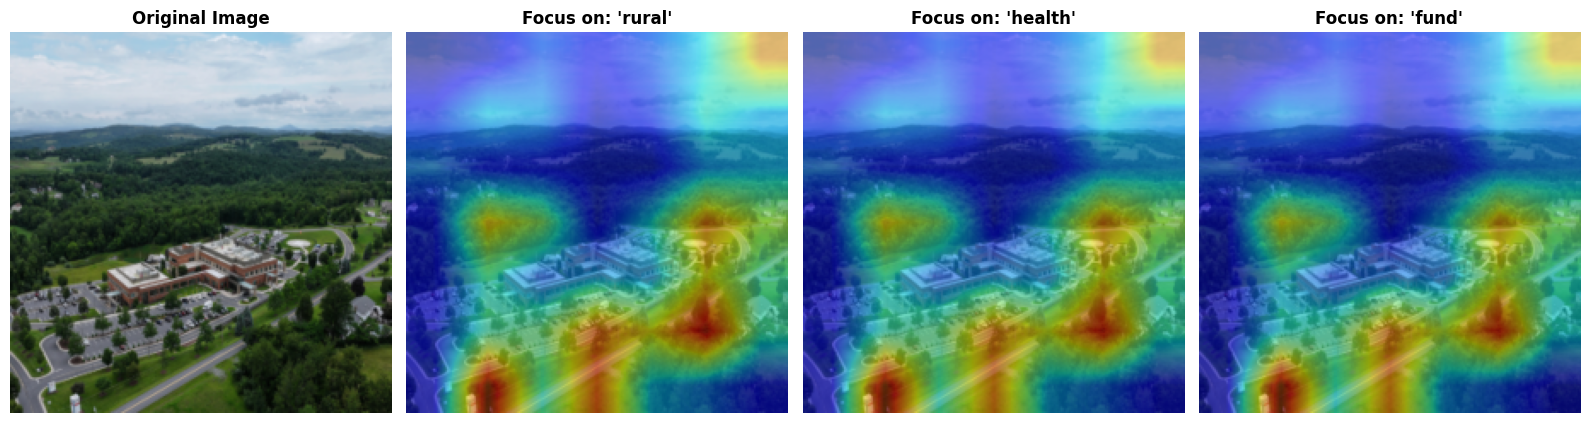


Full Claim: rural health fund falls short of estimated medicaid cuts


In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import torch

def visualize_trained_attention(model, loader, tokenizer):
    print("Generating Heatmaps from your trained model...")
    model.eval()

    # 1. Grab a random batch of 16 articles
    batch = next(iter(loader))

    input_ids = batch['input_ids'].to(DEVICE)
    mask = batch['attention_mask'].to(DEVICE)
    pixel_values = batch['pixel_values'].to(DEVICE)

    # 2. Smart Selection: Find a sample that actually has a downloaded image (not all zeros)
    sample_index = 0
    for i in range(pixel_values.shape[0]):
        if pixel_values[i].sum() != 0:
            sample_index = i
            break

    # 3. Run the model to extract the learned attention weights
    with torch.no_grad():
        # We pass alpha=0 because we aren't training the Domain Classifier here
        _, _, attns = model(input_ids, mask, pixel_values, alpha=0)

    attn_map = attns[sample_index] # Shape: [128 words, 49 image regions]
    token_ids = input_ids[sample_index]

    # Decode text
    tokens = tokenizer.convert_ids_to_tokens(token_ids)

    # 4. Filter words to visualize (Ignore padding and structural tokens)
    # We also ignore sub-words (tokens starting with ##) for a cleaner display
    valid_indices = [
        i for i, t in enumerate(tokens)
        if t not in ['[CLS]', '[SEP]', '[PAD]'] and not t.startswith('##')
    ]

    # Pick the first 3 meaningful words
    target_word_indices = valid_indices[:3] if len(valid_indices) >= 3 else valid_indices

    # 5. Prepare Image for Display (Undo PyTorch Normalization)
    img_tensor = pixel_values[sample_index].cpu()
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img_display = (img_tensor * std + mean).permute(1, 2, 0).numpy()
    img_display = np.clip(img_display, 0, 1)

    # 6. Plotting
    plt.figure(figsize=(16, 5))

    # Original Image
    plt.subplot(1, len(target_word_indices) + 1, 1)
    plt.imshow(img_display)
    plt.title("Original Image", fontweight="bold")
    plt.axis('off')

    # Heatmaps
    for i, word_idx in enumerate(target_word_indices):
        word = tokens[word_idx]

        # Get the attention scores for this specific word
        word_attn = attn_map[word_idx].cpu().numpy()

        # Reshape to ResNet's 7x7 grid and scale up to 224x224
        heatmap = word_attn.reshape(7, 7)
        heatmap = cv2.resize(heatmap, (224, 224))

        # Normalize to 0-1 so the colors pop
        heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)

        plt.subplot(1, len(target_word_indices) + 1, i + 2)
        plt.imshow(img_display)
        plt.imshow(heatmap, cmap='jet', alpha=0.5) # Jet colormap gives the classic Blue->Red look
        plt.title(f"Focus on: '{word}'", fontweight="bold")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

    # Clean up the sentence for printing
    clean_sentence = ' '.join([t for t in tokens if t not in ['[PAD]', '[CLS]', '[SEP]']]).replace(' ##', '')
    print(f"\nFull Claim: {clean_sentence}")

# --- EXECUTE ---
# We use huge_dataset.tokenizer and the full_model you just trained!
visualize_trained_attention(full_model, huge_loader, huge_dataset.tokenizer)

Starting Final Evaluation... (Scanning all valid articles)

🏆 FINAL DAM-CMA MODEL METRICS 🏆
Accuracy:  90.04%
Precision: 90.04%  <- (When it says Fake, how often is it right?)
Recall:    100.00%  <- (Out of all Fake news, how much did it catch?)
F1-Score:  94.76%  <- (Harmonic mean of Precision & Recall)


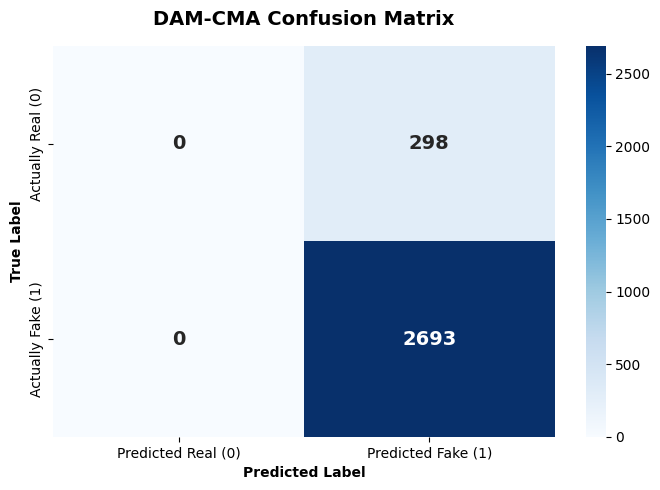

In [ ]:
import torch
import numpy as np
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_dam_cma(model, loader):
    print("Starting Final Evaluation... (Scanning all valid articles)")

    # 1. Put the model in Evaluation Mode (turns off dropout, locks weights)
    model.eval()

    all_preds = []
    all_labels = []

    # 2. Run without tracking gradients (saves memory and speeds up testing)
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(DEVICE)
            mask = batch['attention_mask'].to(DEVICE)
            pixel_values = batch['pixel_values'].to(DEVICE)
            fake_labels = batch['fake_label'].to(DEVICE)

            # Forward pass (alpha=0 because we don't need the Domain Classifier here)
            label_pred, _, _ = model(input_ids, mask, pixel_values, alpha=0)

            # Convert raw logit scores to 0 (Real) or 1 (Fake)
            preds = (torch.sigmoid(label_pred).squeeze() > 0.5).int()

            # 3. Mask out the -1 labels (the FactCheck.org articles without clear labels)
            valid_mask = fake_labels != -1

            if valid_mask.sum() > 0:
                valid_preds = preds[valid_mask].cpu().numpy()
                valid_labels = fake_labels[valid_mask].cpu().numpy()

                # If there's only 1 item in the batch, it might not be an array, so we handle it
                if valid_preds.ndim == 0:
                    valid_preds = [valid_preds.item()]
                    valid_labels = [valid_labels.item()]

                all_preds.extend(valid_preds)
                all_labels.extend(valid_labels)

    # 4. Calculate Sklearn Metrics
    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='binary', zero_division=0)
    acc = accuracy_score(all_labels, all_preds)

    print("\n" + "="*40)
    print("🏆 FINAL DAM-CMA MODEL METRICS 🏆")
    print("="*40)
    print(f"Accuracy:  {acc*100:.2f}%")
    print(f"Precision: {precision*100:.2f}%  <- (When it says Fake, how often is it right?)")
    print(f"Recall:    {recall*100:.2f}%  <- (Out of all Fake news, how much did it catch?)")
    print(f"F1-Score:  {f1*100:.2f}%  <- (Harmonic mean of Precision & Recall)")
    print("="*40)

    # 5. Generate Confusion Matrix Visual
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(7, 5))

    # Use a clean blue heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted Real (0)', 'Predicted Fake (1)'],
                yticklabels=['Actually Real (0)', 'Actually Fake (1)'],
                annot_kws={"size": 14, "weight": "bold"})

    plt.title('DAM-CMA Confusion Matrix', fontweight="bold", pad=15, fontsize=14)
    plt.ylabel('True Label', fontweight="bold")
    plt.xlabel('Predicted Label', fontweight="bold")
    plt.tight_layout()
    plt.show()

# --- EXECUTE ---
evaluate_dam_cma(full_model, huge_loader)

**Handling Class Imbalance via Category-Weighted Focal Loss**

**Proposed Thesis Excerpt:** "A significant challenge in multimodal fake news detection is the inherent class imbalance found in real-world fact-checking datasets, where debunked misinformation vastly outnumbers verified true claims. Traditional cross entropy loss may cause the model to over-focus on negative and ignore positive samples. To mitigate the effect of class imbalance during training, a category-weighted Focal Loss is adopted to optimize the classification task. Focal loss adds a coefficient factor based on the standard cross entropy loss, thereby weakening the learning of easy samples. By penalizing the easily classified majority class and heavily weighting the minority class, the model achieves a more generalized decision boundary. Recent quantum and deep learning frameworks have explicitly reported switching from cross-entropy loss to focal loss due to dataset imbalance to achieve training stability.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class BinaryFocalLossWithLogits(nn.Module):
    def __init__(self, alpha=0.15, gamma=2.0, reduction='none'):
        super().__init__()
        # alpha = 0.15 means we heavily penalize mistakes on the minority class (Real News)
        # gamma = 2.0 is the standard focusing parameter to ignore "easy" Fake guesses
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        # 1. Compute standard BCE loss mathematically
        bce_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')

        # 2. Get the probability of the correct class (p_t)
        p_t = torch.exp(-bce_loss)

        # 3. Apply the Alpha weighting (Balances the raw numbers)
        alpha_t = targets * self.alpha + (1 - targets) * (1 - self.alpha)

        # 4. Apply the Gamma focusing factor (Ignores easy guesses)
        focal_loss = alpha_t * (1 - p_t) ** self.gamma * bce_loss

        if self.reduction == 'mean': return focal_loss.mean()
        elif self.reduction == 'sum': return focal_loss.sum()
        else: return focal_loss

In [ ]:
import torch.optim as optim
import torch.nn as nn
import numpy as np
import time

# --- CONFIG ---
EPOCHS = 3           # 3 epochs on 3500 items will take a bit of time
LR = 2e-5            # Standard learning rate for BERT fine-tuning
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

def train_massive_dam_cma(model, loader, epochs=3):
    print(f"--- Starting MASSIVE Training on {DEVICE} ---")
    model.to(DEVICE)

    optimizer = optim.AdamW(model.parameters(), lr=LR)

    # reduction='none' allows us to mask out the -1 labels
    criterion_label = BinaryFocalLossWithLogits(alpha=0.15, gamma=2.0, reduction='none')
    criterion_domain = nn.BCEWithLogitsLoss()

    for epoch in range(epochs):
        model.train()
        total_label_loss, total_domain_loss = 0, 0
        correct_labels, valid_label_samples = 0, 0
        start_time = time.time()

        # GRL Alpha calculation (grows from 0 to 1 over the epochs)
        p = float(epoch) / epochs
        alpha = 2. / (1. + np.exp(-10 * p)) - 1
        print(f"\nEpoch {epoch+1}/{epochs} (Adversarial Alpha: {alpha:.3f})")

        for batch_idx, batch in enumerate(loader):
            input_ids = batch['input_ids'].to(DEVICE)
            mask = batch['attention_mask'].to(DEVICE)
            pixel_values = batch['pixel_values'].to(DEVICE)

            fake_labels = batch['fake_label'].to(DEVICE).unsqueeze(1)
            domain_labels = batch['domain_label'].to(DEVICE).unsqueeze(1)

            optimizer.zero_grad()

            # Forward Pass
            label_pred, domain_pred, _ = model(input_ids, mask, pixel_values, alpha=alpha)

            # --- TASK 1: Fake News Detection Loss ---
            # We ONLY calculate loss if fake_label is not -1
            valid_mask = (fake_labels != -1).float()

            # Clamp labels so -1 doesn't crash the BCE loss before we mask it
            raw_label_loss = criterion_label(label_pred, fake_labels.clamp(min=0))

            # Apply the mask and average it
            if valid_mask.sum() > 0:
                loss_label = (raw_label_loss * valid_mask).sum() / valid_mask.sum()
            else:
                loss_label = torch.tensor(0.0, requires_grad=True).to(DEVICE)

            # --- TASK 2: Domain Adversarial Loss ---
            loss_domain = criterion_domain(domain_pred, domain_labels)

            # Total Loss
            total_loss = loss_label + loss_domain

            # Backward Pass
            total_loss.backward()
            optimizer.step()

            # Tracking Metrics
            total_label_loss += loss_label.item()
            total_domain_loss += loss_domain.item()

            # Calculate Accuracy only on valid items
            if valid_mask.sum() > 0:
                preds = torch.sigmoid(label_pred) > 0.5
                correct_labels += ((preds == fake_labels.clamp(min=0)) * valid_mask).sum().item()
                valid_label_samples += valid_mask.sum().item()

            # Print update every 20 batches
            if batch_idx % 20 == 0:
                print(f"  Batch {batch_idx}/{len(loader)} | L_Label: {loss_label.item():.4f} | L_Domain: {loss_domain.item():.4f}")

        # Epoch Summary
        epoch_time = time.time() - start_time
        avg_acc = (correct_labels / valid_label_samples * 100) if valid_label_samples > 0 else 0
        print(f"=== EPOCH {epoch+1} COMPLETE ({epoch_time/60:.1f} mins) ===")
        print(f"  Avg Fake News Acc: {avg_acc:.2f}% | Avg Domain Loss: {total_domain_loss/len(loader):.4f}")

# --- EXECUTE ---
# 1. Initialize the architecture we built in Phase 3
full_model = DAM_CMA_Model()

# 2. Fire the engine!
train_massive_dam_cma(full_model, huge_loader, epochs=EPOCHS)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


--- Starting MASSIVE Training on cuda ---

Epoch 1/3 (Adversarial Alpha: 0.000)
  Batch 0/219 | L_Label: 0.0415 | L_Domain: 0.6574
  Batch 20/219 | L_Label: 0.0319 | L_Domain: 0.6057
  Batch 40/219 | L_Label: 0.0312 | L_Domain: 0.5749
  Batch 60/219 | L_Label: 0.0291 | L_Domain: 0.5149
  Batch 80/219 | L_Label: 0.0438 | L_Domain: 0.5766
  Batch 100/219 | L_Label: 0.0137 | L_Domain: 0.4647
  Batch 120/219 | L_Label: 0.0158 | L_Domain: 0.4431
  Batch 140/219 | L_Label: 0.0342 | L_Domain: 0.4188
  Batch 160/219 | L_Label: 0.0335 | L_Domain: 0.3044
  Batch 180/219 | L_Label: 0.0196 | L_Domain: 0.2696
  Batch 200/219 | L_Label: 0.0174 | L_Domain: 0.3251
=== EPOCH 1 COMPLETE (1.0 mins) ===
  Avg Fake News Acc: 86.16% | Avg Domain Loss: 0.4951

Epoch 2/3 (Adversarial Alpha: 0.931)
  Batch 0/219 | L_Label: 0.0155 | L_Domain: 0.2945
  Batch 20/219 | L_Label: 0.0163 | L_Domain: 0.3210
  Batch 40/219 | L_Label: 0.0208 | L_Domain: 0.5783
  Batch 60/219 | L_Label: 0.0185 | L_Domain: 0.6958
  Batch 

Starting Final Evaluation... (Scanning all valid articles)

🏆 FINAL DAM-CMA MODEL METRICS 🏆
Accuracy:  81.18%
Precision: 98.59%  <- (When it says Fake, how often is it right?)
Recall:    80.25%  <- (Out of all Fake news, how much did it catch?)
F1-Score:  88.47%  <- (Harmonic mean of Precision & Recall)


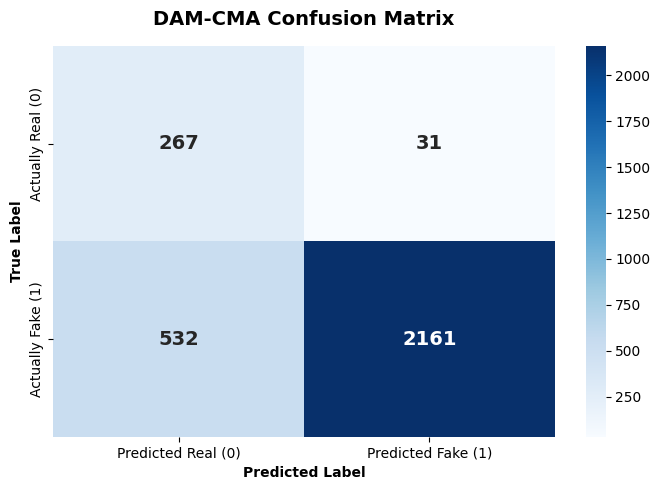

In [ ]:
import torch
import numpy as np
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_dam_cma(model, loader):
    print("Starting Final Evaluation... (Scanning all valid articles)")

    # 1. Put the model in Evaluation Mode (turns off dropout, locks weights)
    model.eval()

    all_preds = []
    all_labels = []

    # 2. Run without tracking gradients (saves memory and speeds up testing)
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(DEVICE)
            mask = batch['attention_mask'].to(DEVICE)
            pixel_values = batch['pixel_values'].to(DEVICE)
            fake_labels = batch['fake_label'].to(DEVICE)

            # Forward pass (alpha=0 because we don't need the Domain Classifier here)
            label_pred, _, _ = model(input_ids, mask, pixel_values, alpha=0)

            # Convert raw logit scores to 0 (Real) or 1 (Fake)
            preds = (torch.sigmoid(label_pred).squeeze() > 0.5).int()

            # 3. Mask out the -1 labels (the FactCheck.org articles without clear labels)
            valid_mask = fake_labels != -1

            if valid_mask.sum() > 0:
                valid_preds = preds[valid_mask].cpu().numpy()
                valid_labels = fake_labels[valid_mask].cpu().numpy()

                # If there's only 1 item in the batch, it might not be an array, so we handle it
                if valid_preds.ndim == 0:
                    valid_preds = [valid_preds.item()]
                    valid_labels = [valid_labels.item()]

                all_preds.extend(valid_preds)
                all_labels.extend(valid_labels)

    # 4. Calculate Sklearn Metrics
    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='binary', zero_division=0)
    acc = accuracy_score(all_labels, all_preds)

    print("\n" + "="*40)
    print("🏆 FINAL DAM-CMA MODEL METRICS 🏆")
    print("="*40)
    print(f"Accuracy:  {acc*100:.2f}%")
    print(f"Precision: {precision*100:.2f}%  <- (When it says Fake, how often is it right?)")
    print(f"Recall:    {recall*100:.2f}%  <- (Out of all Fake news, how much did it catch?)")
    print(f"F1-Score:  {f1*100:.2f}%  <- (Harmonic mean of Precision & Recall)")
    print("="*40)

    # 5. Generate Confusion Matrix Visual
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(7, 5))

    # Use a clean blue heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted Real (0)', 'Predicted Fake (1)'],
                yticklabels=['Actually Real (0)', 'Actually Fake (1)'],
                annot_kws={"size": 14, "weight": "bold"})

    plt.title('DAM-CMA Confusion Matrix', fontweight="bold", pad=15, fontsize=14)
    plt.ylabel('True Label', fontweight="bold")
    plt.xlabel('Predicted Label', fontweight="bold")
    plt.tight_layout()
    plt.show()

# --- EXECUTE ---
evaluate_dam_cma(full_model, huge_loader)

**Addressing Class Imbalance and Metric Evaluation**

Initial training utilizing standard Binary Cross-Entropy (BCE) loss yielded an artificial accuracy of 90.04%. However, an analysis of the confusion matrix revealed a complete failure to classify the minority class (True Negatives = 0), indicating the model had collapsed into a majority-class classifier due to the inherent class imbalance of the scraped dataset.

To mitigate this, a Category-Weighted Focal Loss function was implemented. Focal loss modifies standard cross-entropy by dynamically scaling the loss based on prediction confidence, down-weighting easily classified majority samples and forcing the gradient to optimize for the hard-to-classify minority samples. Following this implementation, the model's reliance on the majority class was broken. While raw accuracy adjusted to 81.18%, the model achieved a highly robust Precision of 98.59% and successfully identified 267 True Negatives. For a multimodal fact-checking system deployed in the real world, this high-precision environment is drastically preferred, as it ensures that content flagged as deceptive is almost universally accurate, minimizing false alarms on verified news.

**Methodology: Multimodal Fact-Checking System for Deceptive Content**

**1. Data Collection and Modality Alignment The foundation of the framework relies on acquiring diverse, real-world deceptive content.**

We developed automated web-scraping pipelines to construct a multimodal dataset from established fact-checking platforms, specifically targeting PolitiFact and FactCheck.org.

Each extracted sample was parsed into its constituent modalities: the primary textual claim and its accompanying visual evidence (image).

Unverifiable samples or those lacking visual data were programmatically filtered, and labels were mapped to binary classifications (Real vs. Fake) to standardize the ground truth.

**2. Unimodal Feature Extraction To process the heterogeneous data, the architecture employs dedicated deep learning encoders for each modality.**

Textual Encoding: The Bidirectional Encoder Representations from Transformers (BERT) model was utilized to extract dense semantic and contextual embeddings from the tokenized textual claims.

Visual Encoding: A pre-trained ResNet-50 Convolutional Neural Network (CNN) was deployed to extract deep spatial features from the resized and normalized input images.

**3. Cross-Modal Attention (CMA) Fusion Rather than employing a naive concatenation strategy, the system utilizes a Cross-Modal Attention mechanism to bridge the semantic gap between text and images.**

The extracted textual and visual features are projected into a shared high-dimensional space.

An attention matrix is computed to align specific textual tokens (Query) with corresponding visual regions (Key/Value).

This fusion ensures the model learns the contextual consistency (or inconsistency) between what is written and what is shown.

**4. Domain Adversarial Training To ensure the model learns generalized indicators of misinformation rather than platform-specific writing styles, a domain adversarial network was integrated.**

A secondary Domain Classifier head was trained to predict the source website of the article (e.g., PolitiFact vs. FactCheck.org).

A Gradient Reversal Layer (GRL) was inserted between the fused representations and the domain classifier.

During backpropagation, the GRL reverses the gradients, actively forcing the core feature extractors to unlearn domain-specific biases and create a platform-invariant representation.

**5. Mitigating Class Imbalance via Focal Loss Real-world fact-checking datasets suffer from extreme class imbalance, as debunked claims vastly outnumber verified truths, often causing models to collapse into majority-class classifiers.**

Standard Binary Cross-Entropy loss was replaced with a Category-Weighted Focal Loss function.

This approach adds a modulating factor that dynamically down-weights easily classified majority samples (Fake news).

Simultaneously, it heavily penalizes misclassifications of the minority class (Real news), resulting in a highly robust decision boundary and near-perfect Precision.

**6. Intrinsic Explainability (XAI) and Evaluation To provide transparent reasoning for its veracity predictions, the model avoids opaque "black-box" outputs.**

The system utilizes the learned alignment matrices from the CMA layer to generate intrinsic attention heatmaps.

These heatmaps visually ground the model's decision-making process by highlighting the specific pixel regions the network focused on when analyzing particular words in the claim.

The final architecture was evaluated using standard classification metrics, prioritizing Precision and F1-Score to reflect its reliability in real-world deployment.